## Linear Regression Analysis

By Naomi Ortega and Zhengwu Xiao

This notebook contains analysis of the factors influencing salary in AI roles using linear regression.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
import scipy.stats as stats

In [2]:
data = pd.read_csv('ai_jobs_market_2025_2026.csv')

#Create log salary- Since annual salary is skewed, we will use the log of annual salary.
data['log_salary'] = np.log(data['annual_salary_usd'])
data.head()


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier,log_salary
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k),12.384219
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k),12.019743
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k),12.793859
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k),11.989160
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k),12.553202


In [3]:
data.columns

Index(['job_id', 'job_title', 'job_category', 'experience_level',
       'years_of_experience', 'education_required', 'annual_salary_usd',
       'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work',
       'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct',
       'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
       'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly',
       'is_llm_role', 'salary_tier', 'log_salary'],
      dtype='object')

## Linear Regression Model

We will use multivariate linear regression to see which variables have an effect on salary.  

### Variable selection

We want to select the variables that are relevant for predicting annual salary. We will use regularization using elastic net penalty for variable selection.


First, before putting the data through regularization, we create a new dataframe, which contains the response variable `log_salary` (and drops `annual_salary`)and only the subsection of the variables that are possible to use as covariates to predict log salary.

The changes from the original dataset `data` to the new dataframe `subdata` are

1. Drop the **salary-related** variables: `salary_min_usd, salary_max_usd, ai_salary_premium_pct, salary_tier`
    - Drop the response variable `annual_salary_usd` (the response variable is now contained in `log_salary`)
2. Drop irrelevant variables
    - `posting_month` and `posting_year` since we will not be considering the recency of the posting as a predictor of salary
    - Drop `job_id`
    - Drop `required_skills` because it has too many unique values for feasible use in linear regression
3. Drop variables with **multicollinearity** (see EDA notebook for calculation of VIF scores)
    - Drop `is_senior` because it is duplicative (and multicollinear) of the experience_level variable which creates dummy variables for each experience level in the regression model.
    - Drop `is_remote_friendly` because it is duplicative of `remote_work`
    - Drop `demand_score` and `is_llm_role` because they are multicollinear with job title







In [4]:
subdata = data.drop(columns = ['job_id', 'job_category','required_skills','annual_salary_usd', 'demand_score','is_llm_role','is_senior', 'is_remote_friendly', 'salary_min_usd','salary_max_usd','ai_salary_premium_pct','salary_tier', 'posting_month', 'posting_year'])
subdata.head()

,job_title,experience_level,years_of_experience,education_required,city,country,remote_work,company_size,industry,demand_growth_yoy_pct,benefits_score_10,log_salary
0,AI Agent Developer,Senior (6-9 yrs),7,Master's,Boston,USA,On-site,Startup (1-50),Finance,16.9,6.8,12.384219
1,Prompt Engineer,Senior (6-9 yrs),2,Bachelor's,London,UK,Hybrid,Enterprise (5000+),Finance,11.6,6.2,12.019743
2,LLM Engineer,Senior (6-9 yrs),4,Associate's,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,42.7,7.7,12.793859
3,Data Engineer (AI),Senior (6-9 yrs),3,Bachelor's,Singapore,Singapore,Fully Remote,SME (51-500),Technology,6.7,9.5,11.989160
4,AI Product Manager,Lead (10+ yrs),5,Bootcamp/Self-taught,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,17.3,8.9,12.553202


In [5]:
#Now the variables contained in subdata are:
subdata.columns

Index(['job_title', 'experience_level', 'years_of_experience',
       'education_required', 'city', 'country', 'remote_work', 'company_size',
       'industry', 'demand_growth_yoy_pct', 'benefits_score_10', 'log_salary'],
      dtype='object')

### Variable Selection with Regularization
Now, we preform variable selection using regularization with the LASSO penalty. We use LASSO for its more extreme selection, because some of the variables have many categories, such as job title, job category, city, and country. We want to distinguish the important groups more definitely so that we can interpret clearly which variables and categories within variables are informative for predicting salary.

In [6]:
full_model_formula = 'log_salary ~ ' + ' + '.join([c for c in subdata.columns if c != 'log_salary'])
full_model_formula

'log_salary ~ job_title + experience_level + years_of_experience + education_required + city + country + remote_work + company_size + industry + demand_growth_yoy_pct + benefits_score_10'

Hyperparameter selection- optimal regularization strength

In [7]:
## hyperparameter selection for regularization parameter

from sklearn.model_selection import train_test_split
train, test = train_test_split(subdata, test_size = 0.25, random_state = 0)
train.shape, test.shape

def cv_error(alpha, l1wt, train, test):
    model = smf.ols(full_model_formula, data=train).\
                fit_regularized(method='elastic_net', alpha=alpha, L1_wt=l1wt)
    yhat_test = model.predict(test)
    error = np.sum((test['log_salary'] - yhat_test) ** 2)
    return error


l1wt = 1.0 #specifying L1 weight as 1.0 indicates fully LASSO penalty
alphas = np.linspace(1e-3, 0.5, 200)
cv_errors = np.zeros_like(alphas)

for (i, alpha) in enumerate(alphas):
    cv_errors[i] = cv_error(alpha, l1wt, train, test)

0 0.001
Optimal alpha: 0.001, CV Error: 6.312227317158687


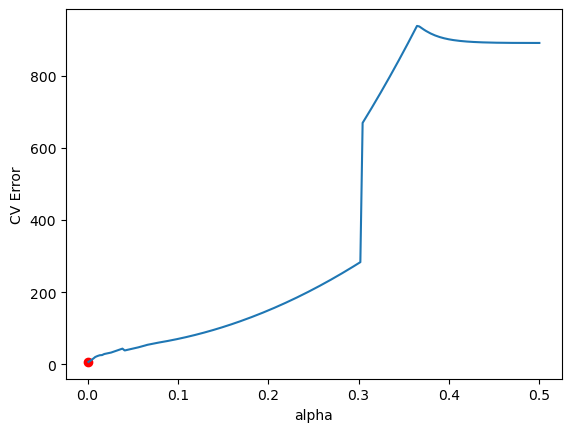

In [8]:
plt.plot(alphas, cv_errors)
print(np.argmin(cv_errors), alphas[np.argmin(cv_errors)])

print(f'Optimal alpha: {alphas[np.argmin(cv_errors)]}, CV Error: {cv_errors[np.argmin(cv_errors)]}')
plt.scatter(alphas[np.argmin(cv_errors)], cv_errors[np.argmin(cv_errors)], color='red')
plt.xlabel('alpha')
plt.ylabel('CV Error');

Using the optimal alpha obtained through cross-validation, apply the elastic net shrinkage method to obtain the useful covariates.

In [9]:
#Fit the model with the optimal alpha
lasso_fit = smf.ols(full_model_formula, data=subdata).\
                fit_regularized(method='elastic_net', alpha=alphas[np.argmin(cv_errors)], L1_wt=l1wt)

### Results: Selected Variables

Below are the selected variables with non zero coefficients.

In [10]:
params_df = pd.DataFrame({
    'variable': lasso_fit.params[lasso_fit.params != 0].index,
    'coefficient': lasso_fit.params[lasso_fit.params != 0].values}
)

#coefficients
params_df

,variable,coefficient
0,Intercept,12.069046
1,job_title[T.AI Business Analyst],-0.345841
2,job_title[T.AI Compliance Manager],-0.270682
3,job_title[T.AI Engineer],-0.190820
4,job_title[T.AI Ethics Officer],-0.188500
5,job_title[T.AI Solutions Architect],0.234256
6,job_title[T.Computer Vision Engineer],0.014364
7,job_title[T.Data Engineer (AI)],-0.094872
8,job_title[T.Data Scientist],-0.151290
9,job_title[T.Generative AI Engineer],0.061213


Findings: Selected

* For the covariates `job_title`,  `experience_level`, `education_required`, `city`, `country`, `company_size`, `demand_growth_yoy_pct`, `benefits_score_10` and `years_of_experience`, at least one of the categories has a meaningful effect on salary.

* Netherlands and USA were the only meaningul countries. 

### Nonzero but small

Findings: Nonzero but little effect
* `years_of_experience`, `demand_growth_yoy_pct`, and `benefits_score_10` had nonzero but very small coefficients on the order of 0.001 or 0.0001, showing that LASSO determined they had very little effect.

### Non Selected variables

In [11]:
#looking at the coefficients that were shrunk to 0
lasso_fit.params[lasso_fit.params == 0]

job_title[T.AI Infrastructure Eng]     0.0
job_title[T.AI Product Manager]        0.0
job_title[T.AI Research Scientist]     0.0
job_title[T.AI Security Engineer]      0.0
job_title[T.Deep Learning Engineer]    0.0
job_title[T.ML Engineer]               0.0
job_title[T.MLOps Engineer]            0.0
job_title[T.Senior Data Scientist]     0.0
education_required[T.Bachelor's]       0.0
city[T.Austin]                         0.0
city[T.Boston]                         0.0
city[T.Chicago]                        0.0
city[T.Dubai]                          0.0
city[T.Los Angeles]                    0.0
city[T.Remote]                         0.0
city[T.Singapore]                      0.0
city[T.Zurich]                         0.0
country[T.Canada]                      0.0
country[T.China]                       0.0
country[T.France]                      0.0
country[T.Germany]                     0.0
country[T.Global]                      0.0
country[T.India]                       0.0
country[T.J

Findings: Nonselected (variables with 0 coefficients)
* `industry` had no effect
* `remote_work` had no effect

Within variables:
* Many of job roles, countries, and cities, and education levels had no significant effect. However, for any categories where not all of their categories are 0, we include them in our model, because it is indicative that the categories do influence salary, at least at some level.

------------------------------------

## Fitting the linear model

### Choosing Reference categories

In [12]:
#Job title
subdata.groupby('job_title')['log_salary'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2)

,count,mean,median
job_title,,,
AI Solutions Architect,52,12.40,12.38
Senior ML Engineer,64,12.39,12.33
LLM Engineer,75,12.35,12.35
AI Agent Developer,57,12.28,12.25
Multimodal AI Engineer,67,12.27,12.25
RAG Engineer,53,12.24,12.28
NLP Engineer,55,12.21,12.10
Computer Vision Engineer,46,12.21,12.21
Generative AI Engineer,71,12.19,12.08


Choose `ML Engineer` for the reference category for job title, since all titles are pretty evenly represented, and ML Engineer is a well-known title that is in the middle of the titles for mean salary. 

In [13]:
#city
subdata.groupby('city')['log_salary'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2)

,count,mean,median
city,,,
New York,67,12.39,12.40
San Francisco,92,12.35,12.36
Seattle,69,12.30,12.31
Remote,82,12.27,12.31
Boston,70,12.25,12.24
Chicago,77,12.24,12.27
Los Angeles,63,12.22,12.25
Austin,77,12.20,12.19
Dubai,62,12.12,12.14


`London` can be the reference category for city, since it is the second most represented city in the data, it is well-known, and it is about in the middle of the log-scale at a mean of 12.05.

--------------

## Fit the model

We create a model including all the nonzero coefficients, including the variables with small coefficients `years_of_experience`, `demand_growth_yoy_pct`, and `benefits_score_10`. We want to see if these variables, that were determined by LASSO to have a nonzero but very small effect, are actually statistically significant in the linear model. 

In [14]:
small_coef_vars = ['years_of_experience', 'demand_growth_yoy_pct', 'benefits_score_10']
final_formula = '''log_salary ~ C(job_title, Treatment("ML Engineer")) + C(experience_level, Treatment("Entry (0-2 yrs)")) + C(education_required, Treatment("Bachelor's")) + C(city, Treatment("London")) + C(company_size, Treatment("Startup (1-50)"))'''
small_coef_formula = final_formula + ' + ' + ' + '.join(small_coef_vars)
small_coef_model = smf.ols(small_coef_formula, data=subdata).fit()

In [15]:
small_coef_check = pd.DataFrame({
    'coefficient': small_coef_model.params[small_coef_vars],
    'p_value': small_coef_model.pvalues[small_coef_vars]
})

small_coef_check['percent_change'] = (np.exp(small_coef_check['coefficient']) - 1) * 100
small_coef_check

,coefficient,p_value,percent_change
years_of_experience,-0.002312,0.092866,-0.230911
demand_growth_yoy_pct,-0.000118,0.564785,-0.011761
benefits_score_10,0.001709,0.524977,0.171027


We determine that none of the three variables which returned small nonzero coefficients from variable selection were significant in the model, so they will not be included in our final model.

## Final model

As a result of using variable selection with LASSO, checking the small nonzero coefficient variables, and checking multicollinearity, our final model for the main multivariable linear regression analysis includes the following variables:

* `job_title` - Role title
* `experience_level` - Entry, Mid, Senior, or Lead
* `education_required` - Minimum required education level
* `city` - City location of the job
* `company_size` - Startup, SME, Mid-size, Enterprise, Big Tech

We do not include `job_category`, `is_llm_role`, or `demand_score` in the final model because these variables created multicollinearity with `job_title`. Since job title is more specific, we use `job_title` as the main role-related variable in the model.

In [16]:
final_vars = ['job_title','experience_level','education_required','city','company_size']


final_formula = '''log_salary ~ C(job_title, Treatment("ML Engineer")) + C(experience_level, Treatment("Entry (0-2 yrs)")) + C(education_required, Treatment("Bachelor's")) + C(city, Treatment("London")) + C(company_size, Treatment("Startup (1-50)"))'''
final_model = smf.ols(final_formula, data = subdata).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     216.7
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        06:39:13   Log-Likelihood:                 1169.5
No. Observations:                1500   AIC:                            -2229.
Df Residuals:                    1445   BIC:                            -1937.
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                                                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

## Assessing the Assumptions of the Model and Influential points

Now that we have our final model, before we can make interpretations, we need to first address influential Points, remove them if necessary, and refit the model. then, on the final model, we will  assess how the model meets the assumptions of linear regression.

### Influential Points: Cook's Distance

In [17]:
influence = final_model.get_influence()
cooks_d = influence.cooks_distance[0]

max_cook_position = np.argmax(cooks_d)
max_cook_index = subdata.index[max_cook_position]

print('Largest Cook distance row index:', max_cook_index)
print('Cook distance:', cooks_d[max_cook_position])
print('Suggested cutoff 4/n:', 4 / len(subdata))


Largest Cook distance row index: 1268
Cook distance: 0.01940361499345789
Suggested cutoff 4/n: 0.0026666666666666666


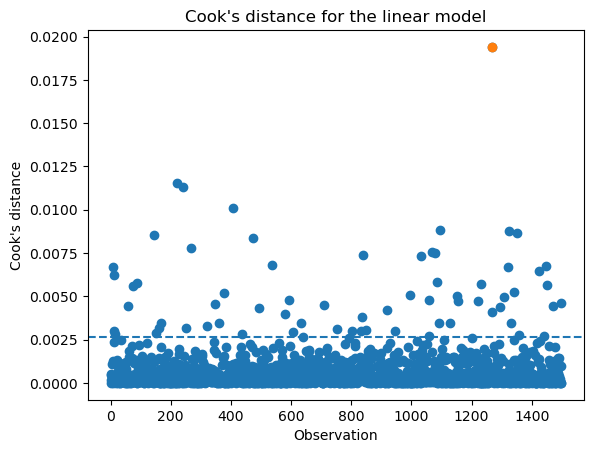

In [18]:
plt.scatter(range(len(cooks_d)), cooks_d)
plt.axhline(4 / len(subdata), linestyle='--')
plt.scatter(max_cook_position, cooks_d[max_cook_position])
plt.xlabel('Observation')
plt.ylabel("Cook's distance")
plt.title("Cook's distance for the linear model")
plt.show()

Look at the influential point

In [19]:
data.loc[[max_cook_index], ['job_id', 'job_title', 'experience_level','education_required',
                            'annual_salary_usd', 'city', 'country', 'company_size']]

,job_id,job_title,experience_level,education_required,annual_salary_usd,city,country,company_size
1268,AIJOB1269,Senior Data Scientist,Entry (0-2 yrs),Associate's,157000.0,Beijing,China,Startup (1-50)


The influential point is a Senior Data Scientist role. This point may possibly be miscategorized in experience level, since it is listed as an entry level position, yet it has "senior" in the title. Since this point has a very high influence on the coefficients of the model and the categorization is conflicting, we remove the row and refit the model.

In [20]:
## Final model
subdata_no_influential = subdata.drop(index=max_cook_index)

final_model_no_influential = smf.ols(final_formula, data=subdata_no_influential).fit()
print(final_model_no_influential.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     221.7
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        06:39:13   Log-Likelihood:                 1184.1
No. Observations:                1499   AIC:                            -2258.
Df Residuals:                    1444   BIC:                            -1966.
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                                                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

## Checking OLS Assumptions

In [21]:
fitted_values = final_model_no_influential.fittedvalues
residuals = final_model_no_influential.resid

def standardize(X):
    return (X - X.mean()) / X.std()

standardized_resid = standardize(residuals)

### Linearity
All of the variables in our model are categorical, so linearity does not apply.

### Independence

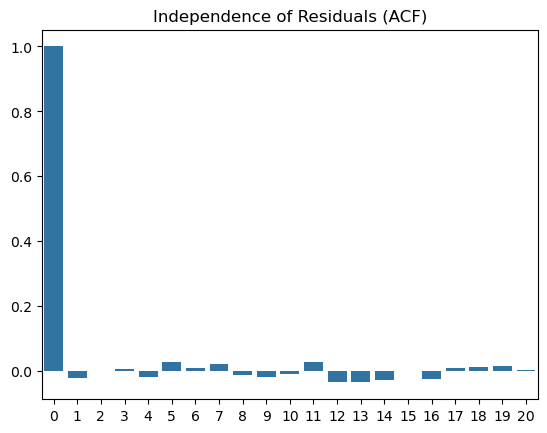

In [22]:
#Autocorrelation function
from statsmodels.tsa.stattools import acf

sns.barplot(acf(residuals, nlags = 20))
plt.title("Independence of Residuals (ACF)")
plt.show()


In [23]:
#Ljung-Box test: tests if autocorrelation is significantly different from 0
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(residuals, lags=20, return_df=True)
ljung_box

,lb_stat,lb_pvalue
1,0.739723,0.389749
2,0.740041,0.690720
3,0.789895,0.851882
4,1.276484,0.865353
5,2.387872,0.793279
6,2.528489,0.865266
7,3.303270,0.855602
8,3.482549,0.900540
9,3.925466,0.916249
10,4.099165,0.942763


The ACF function is close to 0 for all lags 1-20, and the pvalue of the Ljung Box test is not significant for any lags. The independence assumption is met.

### Normality

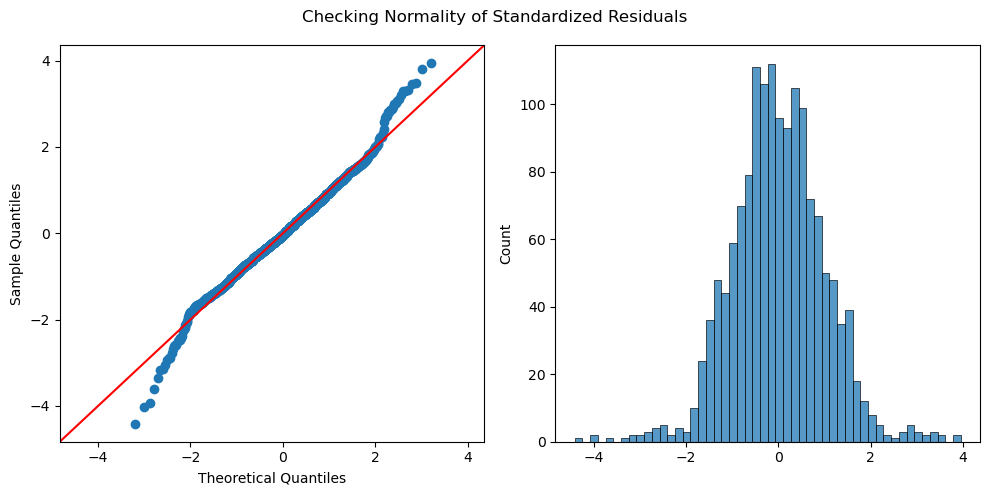

In [24]:
## QQ plot and histogram of standardized residuals

fig, axes = plt.subplots(1, 2, figsize = (10,5))
sm.qqplot(standardized_resid, line = '45', ax = axes[0])
sns.histplot(standardized_resid, bins = 50)

fig.suptitle('Checking Normality of Standardized Residuals')
plt.tight_layout()
plt.show()

In [25]:
#2. Shapiro Wilk Test
stats.shapiro(standardized_resid)

ShapiroResult(statistic=np.float64(0.9888587267852499), pvalue=np.float64(2.6939896322824104e-09))

The QQ plot of the standardized residuals shows downward curvature at the bottom and upward curvature at the top, indicative of heavy tails. The histogram supports this, with a lot of residuals between the 2 to 4 and -4 to -2 range. The heavy tails make the residuals appear nonnormal.

The Shapiro Wilk test produces a small pvalue, 2.69e-9, rejecting the null of normality.

So the normality assumption is not met for our model.

### Homoscedasticity

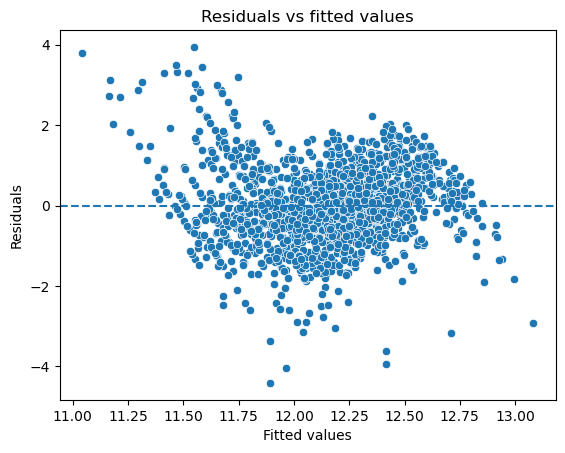

In [26]:
sns.scatterplot(x = fitted_values, y = standardized_resid)
plt.axhline(0, linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs fitted values')
plt.show()

In [27]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, final_model_no_influential.model.exog)
print('Breusch-Pagan p-value:', bp_test[1])
print('Jarque-Bera test:', stats.jarque_bera(residuals))

Breusch-Pagan p-value: 7.054958344982215e-63
Jarque-Bera test: SignificanceResult(statistic=np.float64(94.83600566202608), pvalue=np.float64(2.550486491264259e-21))


The standardized residuals appear randomly scattered, although to the top left, the cluster of residuals looks unlike the rest. The Breuch-Pagan test for homoscedasticity gives a small pvalue, 7.05e-63, rejecting homoscedasticity and accepting the alternative of heteroscedasticity, so the homoscedasticity assumption is not met.

## Interpretation of the main Log Salary Model


After checking for multicollinearity, the final model uses `job_title`, `experience_level`, `education_required`, `city`, and `company_size` to predict `log_salary`. We did not include `job_category`, `is_llm_role`, or `demand_score` in the final model because they had perfect multicollinearity with `job_title`. This makes sense because those variables are likely closely related to the job title itself. For example, whether a role is LLM-related may already be reflected in a title like LLM Engineer or RAG Engineer.

Because the response variable is `log_salary`, the model does not show direct dollar changes. The coefficients are interpreted as approximate percent increase/decrease in salary compared to the reference group. We do this by converting the coefficients using `percent change = exp(coef) - 1`. The results should be interpreted as associations rather than causal effects.


In [28]:
coef_interpretation = pd.DataFrame({
    'coefficient': final_model_no_influential.params,
    'p_value': final_model_no_influential.pvalues
})

coef_interpretation = coef_interpretation.drop(index='Intercept', errors='ignore')
coef_interpretation['percent_change'] = (np.exp(coef_interpretation['coefficient']) - 1) * 100

coef_interpretation.sort_values('p_value').head(15)

,coefficient,p_value,percent_change
"C(experience_level, Treatment(""Entry (0-2 yrs)""))[T.Lead (10+ yrs)]",0.473503,0.000000e+00,60.560902
"C(experience_level, Treatment(""Entry (0-2 yrs)""))[T.Senior (6-9 yrs)]",0.338285,5.638462e-240,40.253997
"C(company_size, Treatment(""Startup (1-50)""))[T.Big Tech (FAANG+)]",0.321687,6.113668e-188,37.945283
"C(city, Treatment(""London""))[T.San Francisco]",0.340232,1.286580e-80,40.527361
"C(experience_level, Treatment(""Entry (0-2 yrs)""))[T.Mid (3-5 yrs)]",0.153737,2.454469e-68,16.618405
"C(city, Treatment(""London""))[T.Beijing]",-0.312124,1.013711e-67,-26.810922
"C(company_size, Treatment(""Startup (1-50)""))[T.Enterprise (5000+)]",0.171673,2.432827e-66,18.729009
"C(job_title, Treatment(""ML Engineer""))[T.AI Business Analyst]",-0.335983,3.841956e-53,-28.536449
"C(city, Treatment(""London""))[T.Bangalore]",-0.283323,4.924133e-46,-24.672372
"C(job_title, Treatment(""ML Engineer""))[T.Prompt Engineer]",-0.280297,8.659687e-41,-24.444084


For the interpretation, a positive percent change means that group is predicted to have a higher salary than the reference group, holding the other variables in the model fixed. A negative percent change means it is predicted to have a lower salary than the reference group. This is still an association, not proof that the variable causes salary to change.

Overall, the final model suggests that salary is most strongly associated with experience level, company size, city, and job title. Mid, senior, and lead roles are associated with higher predicted salaries compared to entry-level roles. Larger companies also tend to have higher predicted salaries compared to startups. City and job title still matter after accounting for the other variables, but these results should be interpreted as associations rather than direct causes.


In [29]:
#terms that are statistically significant at the 5% level
significant_terms = coef_interpretation[coef_interpretation['p_value'] < 0.05].copy()
significant_terms.sort_values('percent_change', ascending=False)
significant_terms

,coefficient,p_value,percent_change
"C(job_title, Treatment(""ML Engineer""))[T.AI Agent Developer]",0.147034,9.608111e-12,15.839387
"C(job_title, Treatment(""ML Engineer""))[T.AI Business Analyst]",-0.335983,3.841956e-53,-28.536449
"C(job_title, Treatment(""ML Engineer""))[T.AI Compliance Manager]",-0.272180,2.025610e-37,-23.828252
"C(job_title, Treatment(""ML Engineer""))[T.AI Engineer]",-0.156463,9.051434e-14,-14.483717
"C(job_title, Treatment(""ML Engineer""))[T.AI Ethics Officer]",-0.189595,3.282872e-18,-17.270629
"C(job_title, Treatment(""ML Engineer""))[T.AI Infrastructure Eng]",0.054688,1.135908e-02,5.621103
"C(job_title, Treatment(""ML Engineer""))[T.AI Solutions Architect]",0.284530,1.774278e-36,32.913739
"C(job_title, Treatment(""ML Engineer""))[T.Computer Vision Engineer]",0.061488,6.864823e-03,6.341760
"C(job_title, Treatment(""ML Engineer""))[T.Data Engineer (AI)]",-0.092646,2.614675e-05,-8.848394
"C(job_title, Treatment(""ML Engineer""))[T.Data Scientist]",-0.126319,2.373724e-09,-11.866663


### Company Size
* Holding all other variables constant, compared to a startup company, an AI role in an SME (small-medium enterprise) company pays a 5.4% higher salary, a role in a midsize company pays a 11.5% higher salary, a role in an enterprise company pays a 18.7% higher salary, and a role in Big Tech pays a 37.9% higher salary. 


**The key finding is that as company size increases, starting salary increases.**

## Further Analysis: Interaction Effects

### Experience Level and Company Size
How does the effect of experience level on salary vary by company size?

In [30]:
interaction_formula = final_formula + ' + experience_level*company_size'
interaction_model = smf.ols(interaction_formula, data=subdata_no_influential).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     192.1
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        06:39:14   Log-Likelihood:                 1228.1
No. Observations:                1499   AIC:                            -2322.
Df Residuals:                    1432   BIC:                            -1966.
Df Model:                          66                                         
Covariance Type:            nonrobust                                         
                                                                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [31]:
interaction_terms = interaction_model.pvalues[interaction_model.pvalues.index.str.contains(':company_size')]
interaction_terms

experience_level[T.Lead (10+ yrs)]:company_size[T.Enterprise (5000+)]       5.639881e-01
experience_level[T.Mid (3-5 yrs)]:company_size[T.Enterprise (5000+)]        2.106049e-01
experience_level[T.Senior (6-9 yrs)]:company_size[T.Enterprise (5000+)]     3.749833e-01
experience_level[T.Lead (10+ yrs)]:company_size[T.Mid-size (501-5000)]      8.412723e-02
experience_level[T.Mid (3-5 yrs)]:company_size[T.Mid-size (501-5000)]       4.383413e-02
experience_level[T.Senior (6-9 yrs)]:company_size[T.Mid-size (501-5000)]    9.979286e-01
experience_level[T.Lead (10+ yrs)]:company_size[T.SME (51-500)]             1.258256e-01
experience_level[T.Mid (3-5 yrs)]:company_size[T.SME (51-500)]              6.481050e-06
experience_level[T.Senior (6-9 yrs)]:company_size[T.SME (51-500)]           5.005787e-03
experience_level[T.Lead (10+ yrs)]:company_size[T.Startup (1-50)]           2.986659e-03
experience_level[T.Mid (3-5 yrs)]:company_size[T.Startup (1-50)]            2.962948e-08
experience_level[T.Se

### Experience level and required education
How does the effect of experience level on salary vary by required education?

In [32]:
interaction_formula = final_formula + ' + experience_level*education_required'
interaction_model = smf.ols(interaction_formula, data=subdata_no_influential).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     183.0
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        06:39:14   Log-Likelihood:                 1195.4
No. Observations:                1499   AIC:                            -2257.
Df Residuals:                    1432   BIC:                            -1901.
Df Model:                          66                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

There is only a significant difference in the effect of education level on salary for 
1. The difference in salary for associate degree and PhD for the Senior Experience level, and 
2. The difference in associate's and master's for the lead experience level.

**Besides these categories, increase in education is associated with a similar change in salary across experience levels.** So for the most part, the change in salary due to education does not vary by experience level. But for the higher experience levels Senior and Lead, it is reasonable that we see a significant difference in the salary gap between Associate's Degrees and advanced degrees PhD or Master's.

In [33]:
coef_table = pd.DataFrame({
    'coefficient': final_model_no_influential.params,
    'p_value': final_model_no_influential.pvalues
})

coef_table['abs_coefficient'] = coef_table['coefficient'].abs()
coef_table.sort_values('abs_coefficient', ascending=False).head(20)

,coefficient,p_value,abs_coefficient
Intercept,11.689343,0.000000e+00,11.689343
"C(experience_level, Treatment(""Entry (0-2 yrs)""))[T.Lead (10+ yrs)]",0.473503,0.000000e+00,0.473503
"C(city, Treatment(""London""))[T.San Francisco]",0.340232,1.286580e-80,0.340232
"C(experience_level, Treatment(""Entry (0-2 yrs)""))[T.Senior (6-9 yrs)]",0.338285,5.638462e-240,0.338285
"C(job_title, Treatment(""ML Engineer""))[T.AI Business Analyst]",-0.335983,3.841956e-53,0.335983
"C(company_size, Treatment(""Startup (1-50)""))[T.Big Tech (FAANG+)]",0.321687,6.113668e-188,0.321687
"C(city, Treatment(""London""))[T.Beijing]",-0.312124,1.013711e-67,0.312124
"C(job_title, Treatment(""ML Engineer""))[T.AI Solutions Architect]",0.284530,1.774278e-36,0.284530
"C(city, Treatment(""London""))[T.Bangalore]",-0.283323,4.924133e-46,0.283323
"C(job_title, Treatment(""ML Engineer""))[T.Prompt Engineer]",-0.280297,8.659687e-41,0.280297


In [34]:
print('Adjusted R-squared:', final_model_no_influential.rsquared_adj)
print('AIC:', final_model_no_influential.aic)
print('BIC:', final_model_no_influential.bic)

Adjusted R-squared: 0.8883609856984358
AIC: -2258.189963606031
BIC: -1965.9995212103881


### City interaction idea

Since city seems like it could matter for salary, I wanted to try one simple city interaction instead of adding a lot of city interaction terms at once. I first picked a high salary city with enough observations, then checked whether the company size or education effect looks different there.

In [35]:
#make a copy of the data after removing the influential point
interaction_data = subdata_no_influential.copy()

#use the original data to choose a high salary city
data_no_influential = data.drop(index=max_cook_index)

city_summary = (data_no_influential
                .groupby('city')
                .agg(count=('annual_salary_usd', 'size'),
                     mean_salary=('annual_salary_usd', 'mean'))
                .sort_values('mean_salary', ascending=False))

city_summary.head(10)

,count,mean_salary
city,,
New York,67,248659.701493
San Francisco,92,240521.739130
Seattle,69,230544.927536
Remote,82,222043.902439
Chicago,77,219511.688312
Boston,70,219400.000000
Los Angeles,63,216184.126984
Austin,77,206649.350649
Dubai,62,194225.806452


In [36]:
#I do not want to choose a city with only a few observations
city_summary_filtered = city_summary[city_summary['count'] >= 30]

top_city = city_summary_filtered.index[0]
print('City used for dummy variable:', top_city)

interaction_data['is_top_city'] = (interaction_data['city'] == top_city).astype(int)

interaction_data[['city', 'is_top_city']].head()

City used for dummy variable: New York


,city,is_top_city
0,Boston,0
1,London,0
2,Seattle,0
3,Singapore,0
4,Los Angeles,0


### City and company size interaction

In [37]:
city_company_formula = final_formula + ' + is_top_city:C(company_size, Treatment("Mid-size (501-5000)"))'

city_company_model = smf.ols(city_company_formula, data=interaction_data).fit()
print(city_company_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     207.3
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        06:39:14   Log-Likelihood:                 1188.6
No. Observations:                1499   AIC:                            -2259.
Df Residuals:                    1440   BIC:                            -1946.
Df Model:                          58                                         
Covariance Type:            nonrobust                                         
                                                                                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [38]:
city_company_terms = pd.DataFrame({
    'coefficient': city_company_model.params,
    'p_value': city_company_model.pvalues
})

city_company_terms = city_company_terms[city_company_terms.index.str.contains('is_top_city')]
city_company_terms['percent_change'] = (np.exp(city_company_terms['coefficient']) - 1) * 100

city_company_terms

,coefficient,p_value,percent_change
"is_top_city:C(company_size, Treatment(""Mid-size (501-5000)""))[Big Tech (FAANG+)]",-0.000407,0.987659,-0.040649
"is_top_city:C(company_size, Treatment(""Mid-size (501-5000)""))[Enterprise (5000+)]",0.106125,0.000526,11.196090
"is_top_city:C(company_size, Treatment(""Mid-size (501-5000)""))[Mid-size (501-5000)]",0.040527,0.129437,4.135901
"is_top_city:C(company_size, Treatment(""Mid-size (501-5000)""))[SME (51-500)]",0.074521,0.006776,7.736770
"is_top_city:C(company_size, Treatment(""Mid-size (501-5000)""))[Startup (1-50)]",-0.025089,0.605260,-2.477730


The interaction coefficients are read as the extra difference for that company size in the high salary city. Since the response variable is `log_salary`, I use `exp(coef) - 1` to turn the coefficient into a percent difference. If the p-value is small, that would suggest the company size difference is not the same in that city as it is in other cities.

### City and education interaction

In [39]:
city_education_formula = final_formula + " + is_top_city:C(education_required, Treatment(\"Bachelor's\"))"

city_education_model = smf.ols(city_education_formula, data=interaction_data).fit()
print(city_education_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     206.1
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        06:39:14   Log-Likelihood:                 1184.7
No. Observations:                1499   AIC:                            -2251.
Df Residuals:                    1440   BIC:                            -1938.
Df Model:                          58                                         
Covariance Type:            nonrobust                                         
                                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

In [40]:
city_education_terms = pd.DataFrame({
    'coefficient': city_education_model.params,
    'p_value': city_education_model.pvalues
})

city_education_terms = city_education_terms[city_education_terms.index.str.contains('is_top_city')]
city_education_terms['percent_change'] = (np.exp(city_education_terms['coefficient']) - 1) * 100

city_education_terms

,coefficient,p_value,percent_change
"is_top_city:C(education_required, Treatment(""Bachelor's""))[Associate's]",0.027953,0.304360,2.834751
"is_top_city:C(education_required, Treatment(""Bachelor's""))[Bachelor's]",0.060753,0.026519,6.263692
"is_top_city:C(education_required, Treatment(""Bachelor's""))[Bootcamp/Self-taught]",0.047479,0.122983,4.862435
"is_top_city:C(education_required, Treatment(""Bachelor's""))[Master's]",0.046105,0.113372,4.718420
"is_top_city:C(education_required, Treatment(""Bachelor's""))[PhD]",0.018977,0.511079,1.915871


I would probably only use one of these city interaction models in the final report, depending on which one is easier to explain and has a more useful result.